In [32]:
import matplotlib.pyplot as plt
import matplotlib
import string
import numpy as np
from ngram_model import *
from game import *

matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['figure.figsize'] = (5.5, 3.5)

data set up

In [33]:
corpus = load_corpus('words_alpha.txt')
train_set, test_set = train_test_split(corpus, 0.95)
train_set, held_out = train_test_split(train_set, 0.9)

Train models

In [ ]:
models = {}
for n in range(1, 4):
    padded = process(train_set, n)
    models[n] = train(padded, n)

lambdas = optimize_lambdas(held_out, models, step=0.1) #took ~3 mins at .05

In [ ]:
#sets lambda for each kind of gram
configs = {
    'Unigram': {1: 1.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0},
    'Bigram': {1: 0.0, 2: 1.0, 3: 0.0, 4: 0.0, 5: 0.0},
    'Trigram': {1: 0.0, 2: 0.0, 3: 1.0, 4: 0.0, 5: 0.0},
    'Interpolated': lambdas
}

intrisic comps

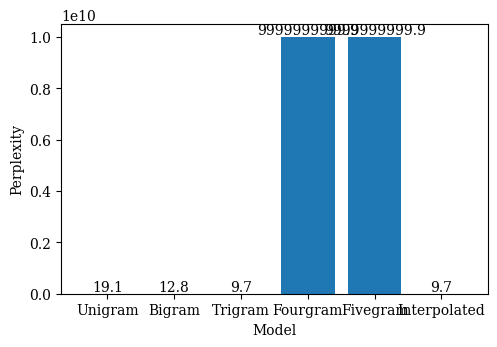

{1: 0.0, 2: 0.0, 3: 1.0}


In [36]:
labels = []
pp_values = []
for name, lam in configs.items():
    pp = perplexity(test_set, models, lam)
    labels.append(name)
    pp_values.append(pp)

plt.bar(labels, pp_values)
for i, v in enumerate(pp_values):
    plt.text(i, v, f'{v:.1f}', ha='center', va='bottom')
plt.xlabel("Model")
plt.ylabel("Perplexity")
plt.savefig('perplexity_vs_model.pdf', bbox_inches='tight')
plt.show()

print(lambdas)

#overleaf stuff
#\begin{figure}[h]
#\includegraphics[width=0.8\linewidth]{perplexity_vs_model.pdf}
#\caption{Perplexity decreases as model complexity increases. The interpolated model achieves the lowest perplexity by combining unigram, bigram, and trigram predictions.}
#\end{figure}

#remark, step size 0.1 and .05 produced same results.

extrinsic comps

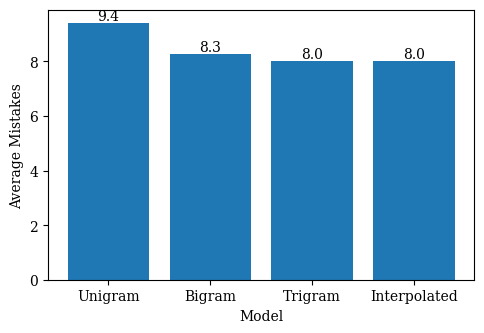

In [6]:
labels = []
mistakes = []
for name, lam in configs.items():
    avg = evaluate(test_set[:100], models, solver, lam)
    labels.append(name)
    mistakes.append(avg)

plt.bar(labels, mistakes)
for i, v in enumerate(mistakes):
    plt.text(i, v, f'{v:.1f}', ha='center', va='bottom')
plt.xlabel("Model")
plt.ylabel("Average Mistakes")
plt.savefig('mistakes_vs_model.pdf', bbox_inches='tight')
plt.show()

#remark: interpolated model uses trigram weights, as noted earlier so, this is an expected result.

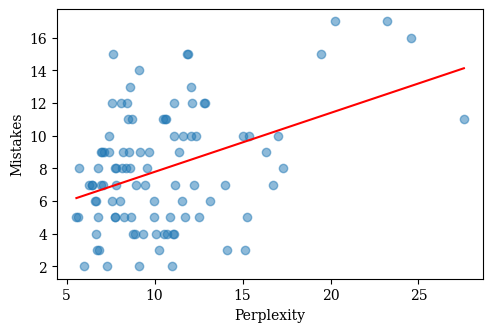

In [16]:
results = []
for word in test_set[:100]:
    m = play_game(word, models, solver, lambdas)
    pp = perplexity([word], models, lambdas)
    results.append((pp, m))

z = np.polyfit(pp_values, mistake_values, 1)
p = np.poly1d(z)
x_line = np.linspace(min(pp_values), max(pp_values), 100)

plt.scatter(pp_values, mistake_values, alpha=0.5)
plt.plot(x_line, p(x_line), color='red')
plt.xlabel("Perplexity")
plt.ylabel("Mistakes")
plt.savefig('perplexity_vs_mistakes.pdf', bbox_inches='tight')
plt.show()

#there was an outlier cooking the plot
#for pp, m in results:
#    if pp > 1000:
#        print(pp, m)

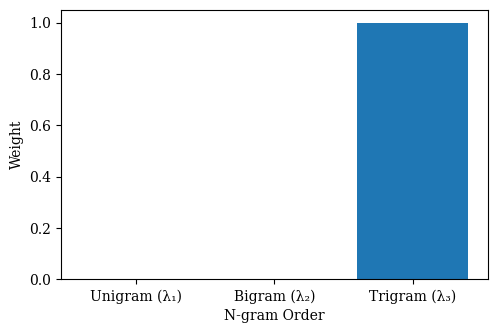

In [ ]:
labels = ['Unigram (λ₁)', 'Bigram (λ₂)', 'Trigram (λ₃)']
weights = [lambdas[1], lambdas[2], lambdas[3]]

plt.bar(labels, weights)
#for i, v in enumerate(weights):
    #plt.text(i, v, f'{v:.1f}', ha='center', va='bottom')
plt.xlabel("N-gram Order")
plt.ylabel("Weight")
plt.savefig('lambda_weights.pdf', bbox_inches='tight')
plt.show()

#remark
#with a sufficiently large training corpus, the trigram model achieves strong enough coverage that lower-order backing off provides no additional benefit.
# maybe a smaller or more specialized corpus would result in the lambdas to be more distributed.

where does the model struggle

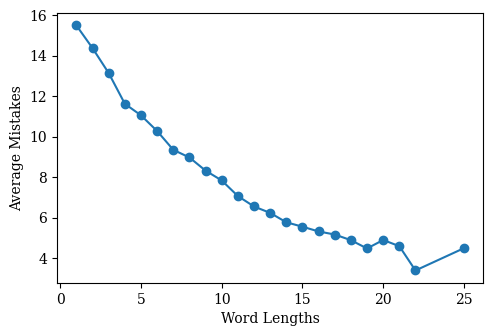

In [18]:
results = []
for word in test_set:
    m = play_game(word, models, solver, lambdas)
    results.append((len(word), m))
#print(results)

groups = {}
for length, m in results:
    if length not in groups:
        groups[length] = []
    groups[length].append(m)
#print(groups)
#remark, the discrepancy in mistakes for same length words may warrant looking at what words/letters the model struggles predicting.

avg_by_length = {}
for length, mistakes in groups.items():
    avg_by_length[length] = sum(mistakes) / len(mistakes)

lengths = sorted(avg_by_length.keys())
avgs = [avg_by_length[l] for l in lengths]

plt.plot(lengths, avgs, marker='o')
plt.xlabel("Word Lengths")
plt.ylabel("Average Mistakes")
#plt.savefig('length_vs_mistake.pdf', bbox_inches='tight')
plt.show()

#remark, Longer words might have more predictable parts like `tion', 'est' while 4 letter words are more unique and harder to predict
#the n-gram model benefits from longer words because more revealed characters provide richer context for predicting the remaining blanks

testing my lambda distribution hypothesis

In [ ]:
fractions = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0]
for frac in fractions:
    subset = train_set[:int(len(train_set) * frac)]
    models = {}
    for n in range(1, 6):
        padded = process(subset, n)
        models[n] = train(padded, n)
    lam = optimize_lambdas(held_out[:100], models, step=0.1)
    pp = perplexity(test_set[:100], models, lam)
    print(f"Training size: {len(subset)}, Lambdas: {lam}, Perplexity: {pp}")

Training size: 3164, Lambdas: {1: 0.09999999999999992, 2: 0.2, 3: 0.7000000000000001}, Perplexity: 10.57869812391268
Training size: 15821, Lambdas: {1: 0.09999999999999998, 2: 0.0, 3: 0.9}, Perplexity: 10.068174561590467
Training size: 31643, Lambdas: {1: 0.09999999999999998, 2: 0.0, 3: 0.9}, Perplexity: 9.971137453338745
Training size: 79109, Lambdas: {1: 0.0, 2: 0.0, 3: 1.0}, Perplexity: 10.176256510888942
Training size: 158219, Lambdas: {1: 0.0, 2: 0.0, 3: 1.0}, Perplexity: 9.977598187007445
Training size: 237329, Lambdas: {1: 0.0, 2: 0.0, 3: 1.0}, Perplexity: 9.965049327938118
Training size: 316439, Lambdas: {1: 0.0, 2: 0.0, 3: 1.0}, Perplexity: 9.962847065118684


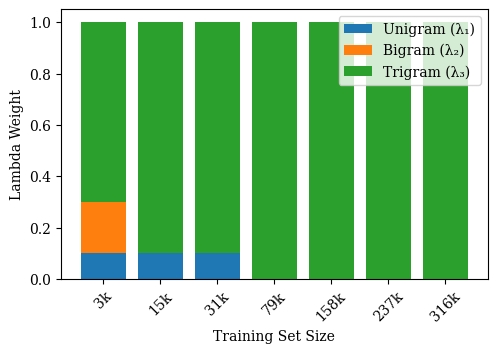

In [ ]:
#remark; indeed for smaller sets, distribution of lambda is more varied

sizes = [3164, 15821, 31643, 79109, 158219, 237329, 316439]
l1 = [0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0]
l2 = [0.2, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
l3 = [0.7, 0.9, 0.9, 1.0, 1.0, 1.0, 1.0]

x = np.arange(len(sizes))
plt.bar(x, l1, label='Unigram (λ₁)')
plt.bar(x, l2, bottom=l1, label='Bigram (λ₂)')
plt.bar(x, l3, bottom=np.array(l1)+np.array(l2), label='Trigram (λ₃)')
plt.xticks(x, [f'{s//1000}k' for s in sizes], rotation=45)
plt.xlabel("Training Set Size")
plt.ylabel("Lambda Weight")
plt.legend()
plt.savefig('lambda_vs_training_size.pdf', bbox_inches='tight')
plt.show()

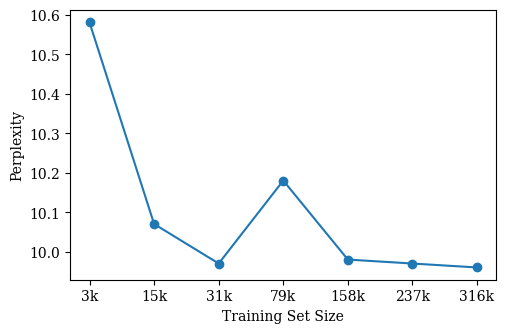

In [22]:
perplexities = [10.58, 10.07, 9.97, 10.18, 9.98, 9.97, 9.96]
sizes = [3164, 15821, 31643, 79109, 158219, 237329, 316439]

plt.plot([f'{s//1000}k' for s in sizes], perplexities, marker='o')
plt.xlabel("Training Set Size")
plt.ylabel("Perplexity")
plt.savefig('perplexity_vs_training_size.pdf', bbox_inches='tight')
plt.show()

confusion analysis, Expected Information Gain or Entropy Reduction of each letter guess

In [4]:
#modification to to capture what the model guesses wrong and what the actual letter was
def play_game_detailed(secret_word, models, solver, lambdas):
    guessed_letters = set()
    mistakes = 0
    confusion = []
    def current_state():
        return [
            c if c in guessed_letters else '_'
            for c in secret_word
        ]
    while '_' in current_state():
        state = current_state()
        guess = solver(state, models, lambdas, guessed_letters)
        guessed_letters.add(guess)
        if guess not in secret_word:
            mistakes += 1
            remaining = set(secret_word) - guessed_letters
            for letter in remaining:
                confusion.append((guess, letter))
    return mistakes, confusion
#Each entry in confusion is a pair: (what was guessed, what was actually needed), giving P(Guess L_j | Word contains L_i)

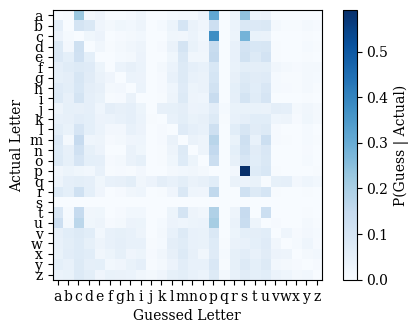

In [ ]:
all_confusion = []
for word in test_set:
    m, conf = play_game_detailed(word, models, solver, lambdas)
    all_confusion.extend(conf)

letters = 'abcdefghijklmnopqrstuvwxyz'
matrix = np.zeros((26, 26))
#since i know the size (only 26 letters in the alphabet), it's cleaner to use a numpy array as opposed to nested dict. like elsewhere
for guessed, actual in all_confusion:
    g_idx = letters.index(guessed)
    a_idx = letters.index(actual)
    matrix[a_idx][g_idx] += 1
row_sums = matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1  # avoid division by zero
matrix_norm = matrix / row_sums

plt.imshow(matrix_norm, cmap='Blues')
plt.xticks(range(26), list(letters))
plt.yticks(range(26), list(letters))
plt.xlabel("Guessed Letter")
plt.ylabel("Actual Letter")
plt.colorbar(label='P(Guess | Actual)')
#plt.savefig('confusion_heatmap.pdf', bbox_inches='tight')
plt.show()

#remark, I'm averaging over very different "regimes" of model behavior,
# the vertical banding might be driven primarily by the early-game frequency-based guesses washing out the later conditional ones.

the model updates based on revealed letters, but the heatmap is aggregating across all game states. So those vertical bands could be mixing together early-game guesses (where the model is essentially following frequency) with late-game guesses (where it has real context)

also the heatmap's cell values are partially influenced by the length distribution of words in the test set, not just the model's behavior. it may not be worth including this visual at all, without addressing this issue

In [10]:
def play_game_detailed(secret_word, models, solver, lambdas):
    guessed_letters = set()
    mistakes = 0
    confusion = []
    def current_state():
        return [c if c in guessed_letters else '_' for c in secret_word]
    while '_' in current_state():
        state = current_state()
        # Fraction of the word currently revealed (0.0 = all blanks, 1.0 = fully revealed)
        revealed_fraction = sum(1 for c in state if c != '_') / len(state)
        guess = solver(state, models, lambdas, guessed_letters, n_max=3)
        guessed_letters.add(guess)
        if guess not in secret_word:
            mistakes += 1
            remaining = set(secret_word) - guessed_letters
            for letter in remaining:
                confusion.append((guess, letter, revealed_fraction))
    return mistakes, confusion

def collect_confusion(test_set, models, solver, lambdas, limit=None):  #limit: optional cap on number of test words (None = use all)
    words = test_set[:limit] if limit else test_set
    all_confusion = []
    for word in words:
        _, conf = play_game_detailed(word, models, solver, lambdas)
        all_confusion.extend(conf)
    return all_confusion #list of guessed_letter, actual_letter, revealed_fraction) tuples

In [30]:
#heatmap, errors in plot fed to llm for bug fixing.
def build_matrix(confusion_data):
    # Simplified mapping using ASCII offset for speed and cleaner code
    matrix = np.zeros((26, 26))
    # Directly unpack the tuple in the loop
    for guess, actual, _ in confusion_data:
        if 'a' <= guess <= 'z' and 'a' <= actual <= 'z':
            matrix[ord(actual) - 97][ord(guess) - 97] += 1
    row_sums = matrix.sum(axis=1, keepdims=True)
    # Safer, more Pythonic numpy division that handles 0s automatically
    matrix = np.divide(matrix, row_sums, out=np.zeros_like(matrix), where=row_sums!=0)
    return matrix

def plot_split_heatmaps(all_confusion, threshold=0.25):
    early = [entry for entry in all_confusion if entry[2] < threshold]
    late  = [entry for entry in all_confusion if entry[2] >= threshold]
    mat_early = build_matrix(early)
    mat_late  = build_matrix(late)
    letters = list(string.ascii_lowercase)
    vmax = max(mat_early.max(), mat_late.max()) 
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
    titles = [
        f'Early Game (< {int(threshold*100)}% revealed)\nn = {len(early)} pairs',
        f'Late Game (≥ {int(threshold*100)}% revealed)\nn = {len(late)} pairs'
    ]
 
# Loop to apply identical styling to both axes (DRY principle)
    for ax, mat, title in zip(axes, [mat_early, mat_late], titles):
        im = ax.imshow(mat, cmap='Blues', aspect='equal', vmin=0, vmax=vmax)
        ax.set_xticks(range(26))
        ax.set_xticklabels(letters, fontsize=7)
        ax.set_yticks(range(26))
        ax.set_yticklabels(letters, fontsize=7)
        ax.set_xlabel('Guessed Letter')
        ax.set_ylabel('Actual Letter')
        ax.set_title(title)
 
   # FIX: Attach colorbar only to the second axis. 
    # fraction=0.046 and pad=0.04 are the standard ratios to match the colorbar height to the plot.
    fig.colorbar(im, ax=axes[1], label='P(Guess | Actual)', fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

#summary
def print_phase_summary(all_confusion, threshold=0.25):
    early = [e for e in all_confusion if e[2] < threshold]
    late  = [e for e in all_confusion if e[2] >= threshold]
 
    print(f"Threshold: {threshold:.0%} of letters revealed")
    print(f"  Early-game pairs: {len(early)}")
    print(f"  Late-game pairs:  {len(late)}")
 
    if early:
        avg_rev_early = np.mean([e[2] for e in early])
        print(f"  Avg revealed (early): {avg_rev_early:.1%}")
    if late:
        avg_rev_late = np.mean([e[2] for e in late])
        print(f"  Avg revealed (late):  {avg_rev_late:.1%}")

Threshold: 25% of letters revealed
  Early-game pairs: 338335
  Late-game pairs:  255380
  Avg revealed (early): 7.0%
  Avg revealed (late):  53.9%


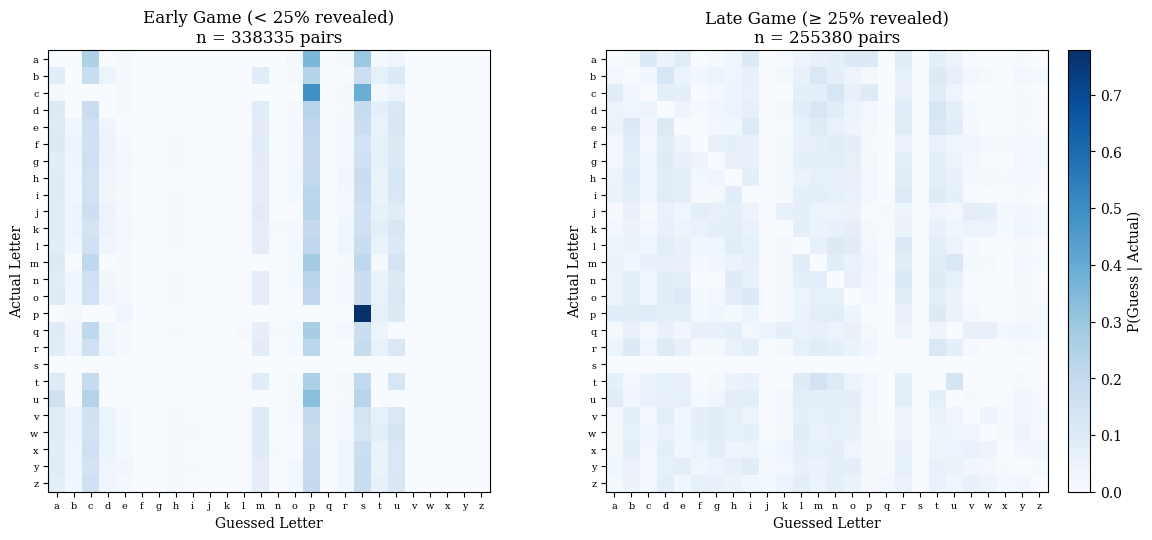

In [31]:
# Run
all_confusion = collect_confusion(test_set, models, solver, lambdas, limit=None)
print_phase_summary(all_confusion, threshold=0.25)
plot_split_heatmaps(all_confusion, threshold=0.25)

Exploring Higher-Order N-grams

In [ ]:
 models = {}
    for n in range(1, 6):
        padded = process(train_set, n)
        models[n] = train(padded, n)

    lambdas = optimize_lambdas(held_out, models, step=0.2)

    uni_avg = evaluate(test_set[:10], models, solver, {1: 1.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0})
    bi_avg = evaluate(test_set[:10], models, solver, {1: 0.0, 2: 1.0, 3: 0.0, 4: 0.0, 5: 0.0})
    tri_avg = evaluate(test_set[:10], models, solver, {1: 0.0, 2: 0.0, 3: 1.0, 4: 0.0, 5: 0.0})
    four_avg = evaluate(test_set[:10], models, solver, {1: 0.0, 2: 0.0, 3: 0.0, 4: 1.0, 5: 0.0})
    five_avg = evaluate(test_set[:10], models, solver, {1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 1.0})
    int_avg = evaluate(test_set[:10], models, solver, lambdas)

    print(f"Unigram: {uni_avg}")
    print(f"Bigram: {bi_avg}")
    print(f"Trigram: {tri_avg}")
    print(f"Fourgram: {four_avg}")
    print(f"Fivegram: {five_avg}")
    print(f"Interpolated: {int_avg}")
    print(lambdas)

def optimize_lambdas(held_out, models, step=0.1):
    best_pp = float('inf')
    best_lambdas = None
    steps = [i * step for i in range(int(1.0 / step) + 1)]
    for l5 in steps:
        for l4 in steps:
            for l3 in steps:
                for l2 in steps:
                    l1 = 1.0 - l5 - l4 - l3 - l2
                    if l1 < 0:
                        continue
                    lambdas = {1: l1, 2: l2, 3: l3, 4: l4, 5: l5}
                    pp = perplexity(held_out, models, lambdas, n_max=5)
                    if pp < best_pp:
                        best_pp = pp
                        best_lambdas = lambdas
    return best_lambdas

def perplexity(test_set, models, lambdas, n_max=5):
    padded = process(test_set, n_max)
    total_log_prob = 0
    total_chars = 0
    for word in padded:
        grams = ngram(word, n_max)
        for gram in grams:
            context = tuple(gram[:-1])
            target = gram[-1]
            prob = interpolate_prob(target, context, models, lambdas)
            if prob == 0:
                prob = 1e-10
            total_log_prob += math.log2(prob)
            total_chars += 1
    pp = 2 ** (-(1/total_chars) * total_log_prob)
    return pp